# House prices — RidgeCV baseline

Daily notebook — small experiment, fully reproducible (seed pinned below).

Synthetic housing data. Ridge with built-in alpha selection, then residual diagnostics.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.linear_model import RidgeCV


## Data

In [ ]:
SEED = 1116

rng = np.random.RandomState(SEED)
n = 3000
sqft = rng.uniform(500, 4000, n).round(0)
bedrooms = rng.choice([1, 2, 3, 4, 5], size=n, p=[0.10, 0.30, 0.35, 0.20, 0.05])
bathrooms = np.clip(bedrooms - rng.choice([0, 1], size=n, p=[0.6, 0.4]), 1, 5)
age_yrs = rng.uniform(0, 60, n).round(1)
neighborhood = rng.choice(["A", "B", "C", "D"], size=n, p=[0.25, 0.35, 0.25, 0.15])
hood_eff = {"A": 42000, "B": 16000, "C": 0, "D": -22000}
price = (80000 + 118 * sqft + 14500 * bedrooms - 850 * age_yrs
         + np.array([hood_eff[x] for x in neighborhood])
         + rng.normal(0, 28000, n))
df = pd.DataFrame({"Sqft": sqft, "Bedrooms": bedrooms, "Bathrooms": bathrooms,
                   "Age": age_yrs, "Neighborhood": neighborhood,
                   "Price": price.round(0).astype(int)})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nmedian price: %d" % int(df["Price"].median()))


shape: (3000, 6)
     Sqft  Bedrooms  Bathrooms   Age Neighborhood   Price
0  3204.0         2          1  10.0            B  524429
1   913.0         3          2  43.9            C  214621
2  2510.0         2          2  21.3            A  453660

median price: 372680


## Model

In [ ]:
num_features = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age']
cat_features = ['Neighborhood']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Price"]); y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
model = Pipeline([("prep", preprocess),
                  ("ridge", RidgeCV(alphas=np.logspace(-2, 4, 9)))])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("best alpha:", model.named_steps["ridge"].alpha_)
print(f"r2: {r2_score(y_test, pred):.4f}")
print(f"rmse: {np.sqrt(mean_squared_error(y_test, pred)):,.0f}")
print(f"mae: {mean_absolute_error(y_test, pred):,.0f}")


best alpha: 0.31622776601683794
r2: 0.9484
rmse: 28,325
mae: 22,810


## Residuals

mean residual: -562.3


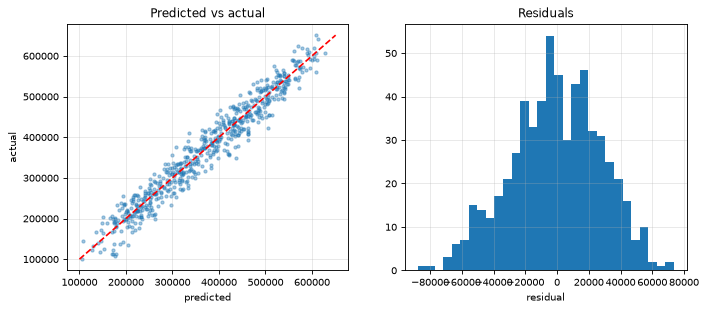

In [ ]:

resid = y_test - pred
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(pred, y_test, s=8, alpha=0.4)
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], "r--")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")
axes[0].set_title("Predicted vs actual")
axes[1].hist(resid, bins=30)
axes[1].set_title("Residuals"); axes[1].set_xlabel("residual")
print("mean residual: %.1f" % resid.mean())


## Notes

- Residuals look roughly symmetric — linear model is a fair baseline.
- RidgeCV picks a small alpha; barely any regularization needed at this n.